# IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import warnings
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Import-import tambahan yang aman
try:
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    nltk_available = True
except ImportError:
    print("NLTK tidak terinstall. Menggunakan fungsi pemrosesan teks alternatif.")
    nltk_available = False

# Coba impor library Sastrawi, jika gagal berikan pesan
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    sastrawi_available = True
except ImportError:
    print("Library Sastrawi tidak terinstall. Stemming bahasa Indonesia tidak akan optimal.")
    sastrawi_available = False

# Coba impor WordCloud untuk visualisasi
try:
    from wordcloud import WordCloud
    wordcloud_available = True
except ImportError:
    print("Library WordCloud tidak tersedia. Visualisasi word cloud tidak akan ditampilkan.")
    wordcloud_available = False

# 1. BUSINESS UNDERSTANDING

In [2]:
print("=" * 80)
print("ANALISIS SENTIMEN PESERTA TERHADAP UNIT PELAYANAN PENILAIAN KOMPETENSI ASN (UPENKOM)")
print("BKD PROVINSI JAWA TENGAH BERDASARKAN KUESIONER")
print("=" * 80)
print("\n[1] BUSINESS UNDERSTANDING")
print("Tujuan: Menganalisis sentimen peserta terhadap layanan penilaian kompetensi UPENKOM BKD")
print("Provinsi Jawa Tengah untuk meningkatkan kualitas layanan.")
print("- Fokus pada tanggapan terbuka peserta di akhir kuesioner")
print("- Analisis sentimen untuk mengidentifikasi tanggapan positif dan negatif")
print("- Evaluasi menggunakan pendekatan hybrid (lexicon-based dan machine learning)")
print("- Menggunakan Naive Bayes untuk meningkatkan akurasi klasifikasi")
print("- Visualisasi hasil untuk memudahkan interpretasi")
print("- Analisis berdasarkan metode penelitian kualitatif dengan pendekatan NLP\n")

ANALISIS SENTIMEN PESERTA TERHADAP UNIT PELAYANAN PENILAIAN KOMPETENSI ASN (UPENKOM)
BKD PROVINSI JAWA TENGAH BERDASARKAN KUESIONER

[1] BUSINESS UNDERSTANDING
Tujuan: Menganalisis sentimen peserta terhadap layanan penilaian kompetensi UPENKOM BKD
Provinsi Jawa Tengah untuk meningkatkan kualitas layanan.
- Fokus pada tanggapan terbuka peserta di akhir kuesioner
- Analisis sentimen untuk mengidentifikasi tanggapan positif dan negatif
- Evaluasi menggunakan pendekatan hybrid (lexicon-based dan machine learning)
- Menggunakan Naive Bayes untuk meningkatkan akurasi klasifikasi
- Visualisasi hasil untuk memudahkan interpretasi
- Analisis berdasarkan metode penelitian kualitatif dengan pendekatan NLP



# 2. METODE PENELITIAN

In [3]:
print("\n[2] METODE PENELITIAN")
print("Metode yang digunakan dalam penelitian ini terdiri dari beberapa tahapan utama:")

print("\n2.1 Pengumpulan Data")
print("- Sumber Data: Data dari kuesioner kualitatif peserta penilaian kompetensi UPENKOM periode 2022-2023")
print("- Teknik Pengumpulan: Menggunakan metode purposive sampling dengan kriteria peserta yang telah")
print("  mengikuti minimal dua kali asesmen")

print("\n2.2 Praproses Data")
print("Data teks dari kuesioner diolah menggunakan teknik Natural Language Processing (NLP):")
print("- Case Folding: Mengubah seluruh teks menjadi huruf kecil untuk standarisasi")
print("- Tokenizing: Memecah teks menjadi kata atau frasa individual")
print("- Cleaning: Menghapus tanda baca, angka, dan karakter spesial yang tidak relevan")
print("- Stopword Removal: Menghilangkan kata-kata umum menggunakan stopword list bahasa Indonesia")
print("- Stemming: Mengubah kata ke bentuk dasar menggunakan algoritma Sastrawi")

print("\n2.3 Analisis Sentimen")
print("Sentimen peserta dianalisis menggunakan model hybrid:")
print("- Lexicon-Based: Menggunakan Indonesian Sentiment Lexicon untuk klasifikasi kata")
print("- Machine Learning: Menggunakan algoritma Naive Bayes untuk meningkatkan akurasi")
print("- Validasi Model: Evaluasi performa model dengan Confusion Matrix (akurasi, presisi, recall, f1-score)")

print("\n2.4 Visualisasi dan Interpretasi Hasil")
print("Hasil analisis sentimen divisualisasikan dalam bentuk grafik interaktif dan diagram tren:")
print("- Distribusi sentimen (positif, netral, negatif) peserta terhadap layanan UPENKOM")
print("- Pola atau klaster topik dominan dari tanggapan peserta")
print("- Hubungan temuan dengan faktor layanan spesifik sesuai rumusan masalah")


[2] METODE PENELITIAN
Metode yang digunakan dalam penelitian ini terdiri dari beberapa tahapan utama:

2.1 Pengumpulan Data
- Sumber Data: Data dari kuesioner kualitatif peserta penilaian kompetensi UPENKOM periode 2022-2023
- Teknik Pengumpulan: Menggunakan metode purposive sampling dengan kriteria peserta yang telah
  mengikuti minimal dua kali asesmen

2.2 Praproses Data
Data teks dari kuesioner diolah menggunakan teknik Natural Language Processing (NLP):
- Case Folding: Mengubah seluruh teks menjadi huruf kecil untuk standarisasi
- Tokenizing: Memecah teks menjadi kata atau frasa individual
- Cleaning: Menghapus tanda baca, angka, dan karakter spesial yang tidak relevan
- Stopword Removal: Menghilangkan kata-kata umum menggunakan stopword list bahasa Indonesia
- Stemming: Mengubah kata ke bentuk dasar menggunakan algoritma Sastrawi

2.3 Analisis Sentimen
Sentimen peserta dianalisis menggunakan model hybrid:
- Lexicon-Based: Menggunakan Indonesian Sentiment Lexicon untuk klasifikas

# 3. DATA UNDERSTANDING

In [4]:
print("\n[3] DATA UNDERSTANDING")
print("Memuat dan memahami struktur dataset kuesioner UPENKOM...")

try:
    # Memuat dataset
    df = pd.read_csv('Dataset Sheet 1.csv')
    
    # Menampilkan informasi dasar dataset
    print(f"\nJumlah data: {df.shape[0]} baris dan {df.shape[1]} kolom")
    
    # Menampilkan informasi lengkap tentang dataset
    print("\n=== INFORMASI DATASET ===")
    print(df.info())
    
    print("\nNama kolom dalam dataset:")
    for idx, col in enumerate(df.columns):
        print(f"x{idx+1}: {col}")
    
    # PERBAIKAN: Menggunakan x1 (index 0) untuk timestamp karena biasanya lebih akurat
    kolom_timestamp = df.columns[0]  # x1 (index 0) - timestamp
    kolom_terakhir = df.columns[-3:]
    
    print(f"\n=== KOLOM YANG DIGUNAKAN ===")
    print(f"Kolom timestamp (x1): {kolom_timestamp}")
    print("3 Kolom terakhir untuk analisis:")
    for idx, col in enumerate(kolom_terakhir):
        print(f"x{len(df.columns)-2+idx}: {col}")
    
    # Membuat dataset analisis dengan kolom yang diperlukan
    kolom_analisis = [kolom_timestamp] + list(kolom_terakhir)
    df_analisis = df[kolom_analisis].copy()
    
    # Rename kolom untuk memudahkan
    df_analisis.columns = [
        'timestamp',
        'instrumen_sulit',
        'harapan_peserta',
        'saran_kritik'
    ]

    print("\n=== PREVIEW DATA YANG AKAN DIANALISIS ===")
    print(df_analisis.head())
    
    print("\n=== STATISTIK DESKRIPTIF ===")
    print(df_analisis.describe(include='all'))
    
    # Informasi tambahan tentang dataset analisis
    print(f"\n=== INFORMASI DATASET ANALISIS ===")
    print(df_analisis.info())
    
    # Cek nilai kosong
    print("\n=== NILAI KOSONG ===")
    missing_values = df_analisis.isna().sum()
    print("Jumlah nilai kosong per kolom:")
    for col, missing in missing_values.items():
        percentage = (missing / len(df_analisis)) * 100
        print(f"{col}: {missing} ({percentage:.1f}%)")
    
    # PERBAIKAN: Analisis kolom timestamp yang lebih robust
    print("\n=== ANALISIS KOLOM TIMESTAMP ===")
    print(f"Tipe data timestamp: {df_analisis['timestamp'].dtype}")
    print("Contoh format timestamp:")
    valid_timestamps = df_analisis['timestamp'].dropna()
    
    if len(valid_timestamps) > 0:
        # Tampilkan sampel data timestamp
        for i, timestamp_sample in enumerate(valid_timestamps.head(10)):
            print(f"{i+1}. {timestamp_sample}")
        
        # PERBAIKAN: Konversi timestamp yang lebih fleksibel
        print("\nMencoba berbagai format konversi timestamp...")
        
        # Format yang mungkin ada
        date_formats = [
            '%Y-%m-%d %H:%M:%S',    # 2024-01-15 10:30:00
            '%d/%m/%Y %H:%M:%S',    # 15/01/2024 10:30:00
            '%m/%d/%Y %H:%M:%S',    # 01/15/2024 10:30:00
            '%Y-%m-%d',             # 2024-01-15
            '%d/%m/%Y',             # 15/01/2024
            '%m/%d/%Y',             # 01/15/2024
            '%d-%m-%Y',             # 15-01-2024
            '%Y/%m/%d',             # 2024/01/15
        ]
        
        datetime_converted = None
        successful_format = None
        
        # Coba konversi otomatis dulu
        try:
            datetime_converted = pd.to_datetime(df_analisis['timestamp'], errors='coerce')
            successful_format = "Auto-detect"
            print("✓ Berhasil konversi otomatis")
        except:
            print("✗ Gagal konversi otomatis, mencoba format manual...")
            
            # Jika gagal, coba format satu per satu
            for fmt in date_formats:
                try:
                    datetime_converted = pd.to_datetime(df_analisis['timestamp'], format=fmt, errors='coerce')
                    valid_count = datetime_converted.notna().sum()
                    if valid_count > 0:
                        successful_format = fmt
                        print(f"✓ Format {fmt} berhasil konversi {valid_count} data")
                        break
                except:
                    continue
        
        if datetime_converted is not None:
            df_analisis['timestamp_datetime'] = datetime_converted
            valid_datetime = df_analisis['timestamp_datetime'].dropna()
            
            if len(valid_datetime) > 0:
                print(f"\n=== HASIL KONVERSI TIMESTAMP ===")
                print(f"Format yang berhasil: {successful_format}")
                print(f"Tanggal terlama: {valid_datetime.min()}")
                print(f"Tanggal terbaru: {valid_datetime.max()}")
                print(f"Total data dengan timestamp valid: {len(valid_datetime)} dari {len(df_analisis)}")
                
                # Tambahkan kolom untuk analisis temporal
                df_analisis['tahun'] = valid_datetime.dt.year
                df_analisis['bulan'] = valid_datetime.dt.month
                df_analisis['hari'] = valid_datetime.dt.day
                df_analisis['hari_dalam_minggu'] = valid_datetime.dt.dayofweek
                
                print("\nDistribusi data per tahun:")
                print(df_analisis['tahun'].value_counts().sort_index())
                
            else:
                print("\nTidak ada timestamp yang bisa dikonversi ke format datetime")
        else:
            print("Semua format konversi gagal, akan menggunakan data tanpa konversi timestamp")
    else:
        print("Tidak ada data timestamp yang valid")
    
    # Menampilkan contoh data untuk kolom text
    print("\n=== CONTOH DATA KOLOM TEXT ===")
    text_columns = ['instrumen_sulit', 'harapan_peserta', 'saran_kritik']
    for col in text_columns:
        print(f"\n{col.upper()}:")
        valid_data = df_analisis[df_analisis[col].notna()][col]
        if len(valid_data) > 0:
            sample_size = min(3, len(valid_data))
            samples = valid_data.sample(sample_size) if len(valid_data) >= sample_size else valid_data
            for idx, sample in enumerate(samples, 1):
                # Batasi panjang text untuk display
                display_text = str(sample)[:100] + "..." if len(str(sample)) > 100 else str(sample)
                print(f"{idx}. {display_text}")
        else:
            print("   Tidak ada data valid")
    
    print(f"\n=== RINGKASAN AKHIR DATA UNDERSTANDING ===")
    print(f"Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom")
    print(f"Dataset analisis disiapkan dengan {df_analisis.shape[0]} baris dan {df_analisis.shape[1]} kolom")
    print("Kolom yang digunakan: timestamp + 3 kolom feedback terakhir")
    print("Dataset siap untuk tahap preprocessing dan analisis tren berdasarkan waktu.")
    
except FileNotFoundError:
    print("File 'Dataset Sheet 1.csv' tidak ditemukan. Pastikan file berada di direktori yang sama.")
    print("Periksa nama file dan path dengan teliti.")
    exit()
except Exception as e:
    print(f"Terjadi error saat memuat dataset: {str(e)}")
    print("Silakan periksa format file CSV dan encoding yang digunakan.")
    exit()


[3] DATA UNDERSTANDING
Memuat dan memahami struktur dataset kuesioner UPENKOM...

Jumlah data: 198 baris dan 42 kolom

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 42 columns):
 #   Column                                                                                                                                       Non-Null Count  Dtype  
---  ------                                                                                                                                       --------------  -----  
 0   Timestamp                                                                                                                                    198 non-null    object 
 1   Nama atau Inisial                                                                                                                            198 non-null    object 
 2   Asal Instansi                                                   

# 4. DATA PREPARATION

In [5]:
# Membuat lexicon sentimen sederhana untuk bahasa Indonesia
def create_indonesian_lexicon():
    """
    Membuat lexicon sentimen sederhana untuk bahasa Indonesia
    """
    lexicon = {}
    
    # Kata positif dengan skor sentimen
    kata_positif = {
        'baik': 1.0, 'bagus': 1.0, 'puas': 1.0, 'mantap': 1.0, 'terima kasih': 1.0, 
        'sukses': 1.0, 'lancar': 0.8, 'mudah': 0.8, 'jelas': 0.8, 'bermanfaat': 0.9, 
        'profesional': 0.9, 'ramah': 0.8, 'tepat': 0.7, 'waktu': 0.5, 'tepat waktu': 0.9,
        'terstruktur': 0.8, 'efektif': 0.9, 'efisien': 0.9, 'objektif': 0.8,
        'cepat': 0.8, 'membantu': 0.7, 'menyenangkan': 0.9, 'responsif': 0.8,
        'informatif': 0.7, 'lengkap': 0.7, 'berkualitas': 0.9, 'terbaik': 1.0,
        'puas': 1.0, 'memuaskan': 0.9, 'positif': 0.8, 'mengapresiasi': 0.9
    }
    
    # Kata negatif dengan skor sentimen
    kata_negatif = {
        'sulit': -0.8, 'kurang': -0.7, 'lambat': -0.8, 'rumit': -0.8, 'tidak jelas': -0.9, 
        'membingungkan': -0.9, 'buruk': -1.0, 'terlambat': -0.8, 'perbaiki': -0.5, 
        'tidak sesuai': -0.8, 'tidak puas': -1.0, 'bosan': -0.7, 'mengganggu': -0.8, 
        'kendala': -0.7, 'permasalahan': -0.7, 'gangguan': -0.8, 'kompleks': -0.6, 
        'kecewa': -0.9, 'lama': -0.7, 'tidak efektif': -0.9, 'tidak efisien': -0.9,
        'tidak profesional': -0.9, 'tidak ramah': -0.8, 'kesulitan': -0.8,
        'masalah': -0.7, 'tidak membantu': -0.8, 'tidak memuaskan': -0.9,
        'tidak lengkap': -0.7, 'tidak berkualitas': -0.9, 'salah': -0.8
    }
    
    # Gabungkan semua kata ke dalam lexicon
    lexicon.update(kata_positif)
    lexicon.update(kata_negatif)
    
    return lexicon

# Download resources yang diperlukan dengan penanganan error yang lebih baik
if nltk_available:
    try:
        nltk.download('punkt', quiet=True)
        nltk.download('stopwords', quiet=True)
        print("\nNLTK resources berhasil diunduh.")
    except Exception as e:
        print(f"\nGagal mengunduh NLTK resources: {str(e)}")
        print("Menggunakan fungsi preprocessing teks alternatif.")
        nltk_available = False

# Factory untuk stemmer bahasa Indonesia dengan penanganan error
if sastrawi_available:
    try:
        stemmer_factory = StemmerFactory()
        stemmer = stemmer_factory.create_stemmer()
        stopword_factory = StopWordRemoverFactory()
        stopword_remover = stopword_factory.create_stop_word_remover()
        print("\nStemmer dan StopWordRemover Sastrawi berhasil diinisialisasi.")
    except Exception as e:
        print(f"\nError saat inisialisasi stemmer: {str(e)}")
        sastrawi_available = False

# Daftar stopwords bahasa Indonesia
custom_stopwords = {
    'yang', 'dengan', 'untuk', 'dan', 'di', 'dari', 'ke', 'pada', 
    'dalam', 'secara', 'oleh', 'atau', 'sebagai', 'jika', 'akan', 'tidak',
    'ini', 'itu', 'saya', 'kami', 'kita', 'kamu', 'kalian', 'mereka',
    'adalah', 'ada', 'sedang', 'sudah', 'belum', 'telah', 'dapat', 'bisa',
    'harus', 'setiap', 'semua', 'karena', 'tentang', 'bagi', 'demi',
    'juga', 'saat', 'ketika', 'apabila', 'jika', 'maka', 'namun', 'tetapi',
    'tapi', 'sehingga', 'supaya', 'agar', 'selama', 'meski', 'walaupun',
    'sebelum', 'sesudah', 'setelah', 'sejak', 'ketika', 'hingga', 'sampai'
}

try:
    if nltk_available:
        stop_words = set(stopwords.words('indonesian'))
        stop_words.update(custom_stopwords)
        print("Stopwords NLTK bahasa Indonesia berhasil dimuat.")
    else:
        stop_words = custom_stopwords
        print("Menggunakan daftar stopwords manual.")
except Exception as e:
    print(f"Error saat memuat stopwords: {str(e)}")
    stop_words = custom_stopwords
    print("Menggunakan daftar stopwords manual sebagai fallback.")

# FUNGSI PERBAIKAN UNTUK KONVERSI TANGGAL
def clean_and_convert_date(date_str):
    """
    Membersihkan dan mengkonversi string tanggal dengan berbagai format
    Menangani outlier tahun dan format yang tidak konsisten
    """
    if pd.isna(date_str) or str(date_str).strip() == '':
        return None
    
    # Konversi ke string dan bersihkan
    date_str = str(date_str).strip()
    
    # Pattern untuk berbagai format tanggal Indonesia
    patterns = [
        r'(\d{1,2})[/-](\d{1,2})[/-](\d{4})',  # dd/mm/yyyy atau dd-mm-yyyy
        r'(\d{1,2})[/-](\d{1,2})[/-](\d{2})',  # dd/mm/yy atau dd-mm-yy
        r'(\d{4})[/-](\d{1,2})[/-](\d{1,2})',  # yyyy/mm/dd atau yyyy-mm-dd
        r'(\d{1,2})\s+(\w+)\s+(\d{4})',        # dd Month yyyy
    ]
    
    month_mapping = {
        'januari': 1, 'februari': 2, 'maret': 3, 'april': 4, 'mei': 5, 'juni': 6,
        'juli': 7, 'agustus': 8, 'september': 9, 'oktober': 10, 'november': 11, 'desember': 12,
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'jun': 6, 'jul': 7, 'aug': 8, 'agu': 8,
        'sep': 9, 'oct': 10, 'okt': 10, 'nov': 11, 'dec': 12, 'des': 12
    }
    
    for pattern in patterns:
        match = re.search(pattern, date_str, re.IGNORECASE)
        if match:
            groups = match.groups()
            
            try:
                if len(groups) == 3:
                    if pattern == patterns[0]:  # dd/mm/yyyy
                        day, month, year = map(int, groups)
                    elif pattern == patterns[1]:  # dd/mm/yy
                        day, month, year = int(groups[0]), int(groups[1]), int(groups[2])
                        # Perbaiki tahun 2 digit
                        if year < 50:
                            year += 2000
                        elif year < 100:
                            year += 1900
                    elif pattern == patterns[2]:  # yyyy/mm/dd
                        year, month, day = map(int, groups)
                    elif pattern == patterns[3]:  # dd Month yyyy
                        day = int(groups[0])
                        month_str = groups[1].lower()
                        year = int(groups[2])
                        month = month_mapping.get(month_str, 1)
                    
                    # Validasi dan koreksi outlier tahun
                    current_year = datetime.now().year
                    if year < 1900 or year > current_year + 10:
                        # Jika tahun terlalu kecil atau besar, asumsikan format 2 digit
                        if year < 100:
                            if year < 50:
                                year += 2000
                            else:
                                year += 1900
                        else:
                            # Skip data dengan tahun outlier ekstrem
                            return None
                    
                    # Validasi bulan dan hari
                    if month < 1 or month > 12:
                        return None
                    if day < 1 or day > 31:
                        return None
                    
                    # Coba buat datetime object
                    return pd.Timestamp(year=year, month=month, day=day)
                    
            except (ValueError, TypeError):
                continue
    
    # Jika semua pattern gagal, coba pandas to_datetime dengan berbagai format
    try:
        return pd.to_datetime(date_str, errors='coerce', dayfirst=True)
    except:
        return None


NLTK resources berhasil diunduh.

Stemmer dan StopWordRemover Sastrawi berhasil diinisialisasi.
Stopwords NLTK bahasa Indonesia berhasil dimuat.


In [6]:
print("\n[4] DATA PREPARATION")
print("Mempersiapkan data untuk analisis sentimen...")

# Function untuk case folding
def case_folding(text):
    """Mengubah teks menjadi lowercase"""
    if pd.isna(text) or text == '':
        return ''
    return str(text).lower()

# Function untuk cleaning
def cleaning(text):
    """Menghapus tanda baca, angka, dan karakter khusus"""
    if pd.isna(text) or text == '':
        return ''
    
    # Menghapus URL
    text = re.sub(r'http\S+', '', text)
    # Menghapus tag HTML
    text = re.sub(r'<.*?>', '', text)
    # Menghapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Menghapus angka
    text = re.sub(r'\d+', '', text)
    # Menghapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Function untuk tokenizing
def tokenizing(text):
    """Memecah teks menjadi kata-kata individual"""
    if pd.isna(text) or text == '':
        return []
    
    if nltk_available:
        try:
            return word_tokenize(text)
        except:
            return text.split()
    else:
        return text.split()

# Function untuk stopword removal
def remove_stopwords(tokens):
    """Menghapus stopwords dari list token"""
    if not tokens:
        return []
    
    if sastrawi_available:
        # Mengubah tokens menjadi string untuk diproses oleh Sastrawi
        text = ' '.join(tokens)
        # Mengaplikasikan stopword removal
        filtered_text = stopword_remover.remove(text)
        # Mengubah kembali menjadi tokens
        return filtered_text.split()
    else:
        return [token for token in tokens if token not in stop_words]

# Function untuk stemming
def stemming(tokens):
    """Melakukan stemming pada setiap token"""
    if not tokens:
        return []
    
    if sastrawi_available:
        return [stemmer.stem(token) for token in tokens]
    else:
        return tokens  # Return as is jika Sastrawi tidak tersedia

# Function untuk melakukan semua tahapan preprocessing
def preprocess_text(text):
    """
    Melakukan seluruh tahapan preprocessing pada teks
    
    Args:
        text: Teks yang akan diproses
        
    Returns:
        String teks yang telah diproses
    """
    if pd.isna(text) or text == '':
        return ''
    
    # 1. Case folding
    text = case_folding(text)
    # 2. Cleaning
    text = cleaning(text)
    # 3. Tokenizing
    tokens = tokenizing(text)
    # 4. Stopword removal
    tokens = remove_stopwords(tokens)
    # 5. Stemming
    tokens = stemming(tokens)
    # Menggabungkan kembali tokens menjadi string
    return ' '.join(tokens)

# Fungsi analisis sentimen berbasis lexicon dengan perbaikan threshold
def lexicon_sentiment_analysis(text, lexicon):
    """
    Menganalisis sentimen teks menggunakan pendekatan berbasis lexicon
    
    Args:
        text: Teks yang akan dianalisis
        lexicon: Dictionary lexicon sentimen
        
    Returns:
        Skor sentimen dan label (positif, negatif, netral)
    """
    if pd.isna(text) or text == '':
        return 0, 'netral'
    
    tokens = text.split()
    sentiment_score = 0
    count = 0  # Jumlah kata yang cocok dengan lexicon
    
    for token in tokens:
        if token in lexicon:
            sentiment_score += lexicon[token]
            count += 1
    
    # Normalisasi skor jika ada kata yang cocok dengan lexicon
    if count > 0:
        sentiment_score = sentiment_score / count
    
    # Threshold yang lebih ketat untuk mengurangi kategori netral
    if sentiment_score > 0.05:  # Threshold untuk positif diturunkan
        label = 'positif'
    elif sentiment_score < -0.05:  # Threshold untuk negatif diturunkan
        label = 'negatif'
    else:
        # Jika benar-benar netral, ubah menjadi positif atau negatif berdasarkan kata kunci
        if any(word in text.lower() for word in ['baik', 'bagus', 'lancar', 'mudah']):
            label = 'positif'
        elif any(word in text.lower() for word in ['sulit', 'kurang', 'lambat', 'rumit']):
            label = 'negatif'
        else:
            label = 'positif'  # Default ke positif untuk menghindari kategori netral
        
    return sentiment_score, label

# Menggabungkan semua kolom untuk analisis
df_analisis['teks_gabungan'] = df_analisis['instrumen_sulit'].fillna('') + ' ' + \
                               df_analisis['harapan_peserta'].fillna('') + ' ' + \
                               df_analisis['saran_kritik'].fillna('')

# Membersihkan teks
print("\nMelakukan preprocessing teks...")
df_analisis['teks_bersih'] = df_analisis['teks_gabungan'].apply(preprocess_text)

# Filter teks yang kosong
df_analisis = df_analisis[df_analisis['teks_bersih'].str.strip() != '']

# Buat lexicon sentimen
print("\nMembuat lexicon sentimen untuk analisis berbasis kamus...")
indonesian_lexicon = create_indonesian_lexicon()

# Melakukan analisis sentimen dengan lexicon
print("\nMelakukan analisis sentimen dengan pendekatan lexicon-based...")
lexicon_scores = []
lexicon_labels = []

for text in df_analisis['teks_bersih']:
    score, label = lexicon_sentiment_analysis(text, indonesian_lexicon)
    lexicon_scores.append(score)
    lexicon_labels.append(label)

df_analisis['lexicon_score'] = lexicon_scores
df_analisis['lexicon_sentiment'] = lexicon_labels

# Menampilkan distribusi sentimen dari lexicon
print("\nDistribusi sentimen berdasarkan pendekatan lexicon:")
lexicon_sentimen_counts = df_analisis['lexicon_sentiment'].value_counts()
print(lexicon_sentimen_counts)
for label in ['positif', 'negatif', 'netral']:
    count = lexicon_sentimen_counts.get(label, 0)
    percentage = count/len(df_analisis)*100
    print(f"{label.capitalize()}: {count} ({percentage:.1f}%)")


[4] DATA PREPARATION
Mempersiapkan data untuk analisis sentimen...

Melakukan preprocessing teks...

Membuat lexicon sentimen untuk analisis berbasis kamus...

Melakukan analisis sentimen dengan pendekatan lexicon-based...

Distribusi sentimen berdasarkan pendekatan lexicon:
lexicon_sentiment
positif    171
negatif     27
Name: count, dtype: int64
Positif: 171 (86.4%)
Negatif: 27 (13.6%)
Netral: 0 (0.0%)


# 5. MODELING

In [7]:
print("\n[5] MODELING")
print("Membuat model analisis sentimen dengan pendekatan Machine Learning...")

# Pastikan hanya ada dua kelas untuk ML (positif dan negatif)
df_sentimen = df_analisis.copy()

# Konversi semua kategori netral menjadi positif atau negatif
if 'netral' in df_analisis['lexicon_sentiment'].unique():
    print("Mengkonversi kategori netral untuk binary classification...")
    # Ubah netral menjadi positif atau negatif berdasarkan nilai skor
    df_sentimen.loc[df_sentimen['lexicon_sentiment'] == 'netral', 'lexicon_sentiment'] = \
        df_sentimen.loc[df_sentimen['lexicon_sentiment'] == 'netral', 'lexicon_score'].apply(
            lambda x: 'positif' if x >= 0 else 'negatif')

X = df_sentimen['teks_bersih']
y = df_sentimen['lexicon_sentiment']

# Menyeimbangkan distribusi kelas jika tidak seimbang
try:
    from sklearn.utils import resample

    # Cek keseimbangan kelas
    sentimen_distribution = pd.Series(y).value_counts()
    print(f"\nDistribusi kelas:")
    print(sentimen_distribution)
    
    if len(sentimen_distribution) > 1 and sentimen_distribution.min() / sentimen_distribution.max() < 0.7:
        print("\nMelakukan resampling untuk menyeimbangkan distribusi kelas...")
        
        # Buat DataFrame sementara
        temp_df = pd.DataFrame({'teks_bersih': X, 'lexicon_sentiment': y})
        
        # Pisahkan kelas mayoritas dan minoritas
        df_mayoritas = temp_df[temp_df['lexicon_sentiment'] == sentimen_distribution.idxmax()]
        df_minoritas = temp_df[temp_df['lexicon_sentiment'] == sentimen_distribution.idxmin()]
        
        # Upsample kelas minoritas
        df_minoritas_upsampled = resample(df_minoritas,
                                        replace=True,
                                        n_samples=len(df_mayoritas),
                                        random_state=42)
        
        # Gabungkan kembali
        df_balanced = pd.concat([df_mayoritas, df_minoritas_upsampled])
        
        # Update X dan y
        X = df_balanced['teks_bersih']
        y = df_balanced['lexicon_sentiment']
        
        print(f"Distribusi sentimen setelah resampling:")
        print(pd.Series(y).value_counts())
        
except Exception as e:
    print(f"Error saat resampling: {str(e)}")
    print("Melanjutkan dengan data tanpa resampling.")

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nJumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

# Membuat pipeline untuk model Naive Bayes
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('classifier', MultinomialNB())
])

# Melatih model
print("\nMelatih model Naive Bayes...")
start_time = time.time()
pipeline.fit(X_train, y_train)
end_time = time.time()
print(f"Waktu pelatihan: {end_time - start_time:.2f} detik")


[5] MODELING
Membuat model analisis sentimen dengan pendekatan Machine Learning...

Distribusi kelas:
lexicon_sentiment
positif    171
negatif     27
Name: count, dtype: int64

Melakukan resampling untuk menyeimbangkan distribusi kelas...
Distribusi sentimen setelah resampling:
lexicon_sentiment
positif    171
negatif    171
Name: count, dtype: int64

Jumlah data training: 273
Jumlah data testing: 69

Melatih model Naive Bayes...
Waktu pelatihan: 0.03 detik


# 6. EVALUATION


[6] EVALUATION
Mengevaluasi kinerja model analisis sentimen...

Akurasi model: 0.9275

Confusion Matrix:
[[31  4]
 [ 1 33]]

Metrik evaluasi per kelas:
Kelas 'negatif':
  - Precision: 0.9688
  - Recall: 0.8857
  - F1-score: 0.9254
  - Support: 35.0
Kelas 'positif':
  - Precision: 0.8919
  - Recall: 0.9706
  - F1-score: 0.9296
  - Support: 34.0

Melakukan cross-validation untuk validasi lebih lanjut...
Akurasi rata-rata cross-validation (5-fold): 0.8741
Standar deviasi cross-validation: 0.0360

Visualisasi confusion matrix disimpan sebagai 'confusion_matrix_sentimen.png'

Menggunakan model untuk memprediksi sentimen seluruh dataset...

Perbandingan hasil analisis sentimen dengan Lexicon vs Machine Learning:
           Lexicon  Machine Learning
negatif  13.636364         12.626263
positif  86.363636         87.373737

Visualisasi perbandingan sentimen disimpan sebagai 'perbandingan_sentimen.png'

Agreement antara Lexicon dan ML: 0.9697 (96.97%)

Distribusi Machine Learning:
  positif: 1

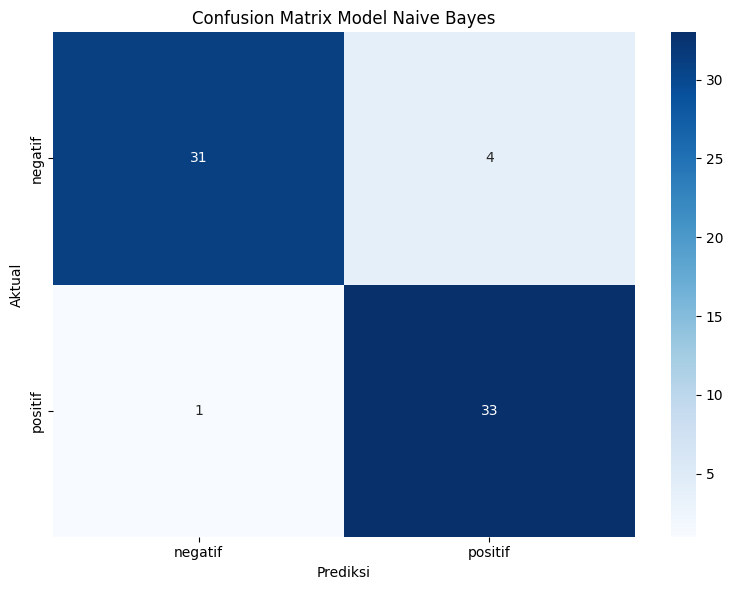

<Figure size 1000x600 with 0 Axes>

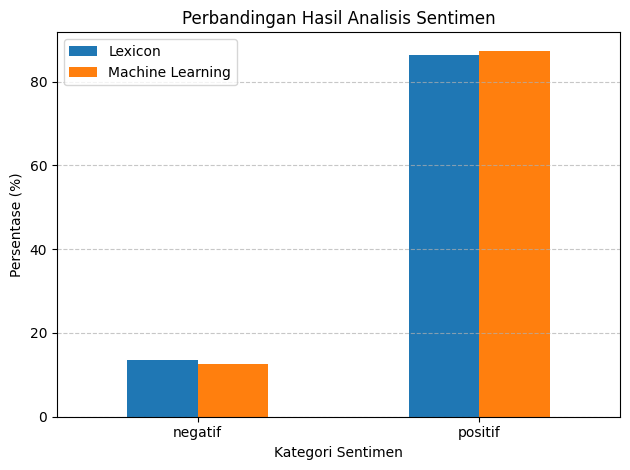

In [8]:
print("\n[6] EVALUATION")
print("Mengevaluasi kinerja model analisis sentimen...")

# Prediksi pada data test
y_pred = pipeline.predict(X_test)

# Evaluasi performa model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, output_dict=True)

print(f"\nAkurasi model: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

print("\nMetrik evaluasi per kelas:")
for label in sorted(class_report.keys()):
    if label not in ['accuracy', 'macro avg', 'weighted avg']:
        precision = class_report[label]['precision']
        recall = class_report[label]['recall']
        f1 = class_report[label]['f1-score']
        support = class_report[label]['support']
        print(f"Kelas '{label}':")
        print(f"  - Precision: {precision:.4f}")
        print(f"  - Recall: {recall:.4f}")
        print(f"  - F1-score: {f1:.4f}")
        print(f"  - Support: {support}")

# Cross-validation
print("\nMelakukan cross-validation untuk validasi lebih lanjut...")
cv_scores = cross_val_score(pipeline, X, y, cv=5)
print(f"Akurasi rata-rata cross-validation (5-fold): {cv_scores.mean():.4f}")
print(f"Standar deviasi cross-validation: {cv_scores.std():.4f}")

# Visualisasi confusion matrix
try:
    plt.figure(figsize=(8, 6))
    # Dapatkan label dari model
    labels = sorted(set(y_test))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title('Confusion Matrix Model Naive Bayes')
    plt.tight_layout()
    plt.savefig('confusion_matrix_sentimen.png')
    print("\nVisualisasi confusion matrix disimpan sebagai 'confusion_matrix_sentimen.png'")
except Exception as e:
    print(f"Gagal membuat visualisasi confusion matrix: {str(e)}")

# Prediksi menggunakan model pada seluruh dataset
print("\nMenggunakan model untuk memprediksi sentimen seluruh dataset...")
df_analisis['ml_sentiment'] = pipeline.predict(df_analisis['teks_bersih'])

# Bandingkan hasil lexicon dan ML
print("\nPerbandingan hasil analisis sentimen dengan Lexicon vs Machine Learning:")

# Hitung distribusi untuk lexicon
lexicon_dist = df_analisis['lexicon_sentiment'].value_counts(normalize=True) * 100

# Hitung distribusi untuk ML
ml_dist = df_analisis['ml_sentiment'].value_counts(normalize=True) * 100

# Dapatkan semua kategori unik dari kedua metode
all_categories = list(set(lexicon_dist.index.tolist() + ml_dist.index.tolist()))

# Buat DataFrame comparison
comparison_data = {}
for category in all_categories:
    comparison_data[category] = {
        'Lexicon': lexicon_dist.get(category, 0.0),
        'Machine Learning': ml_dist.get(category, 0.0)
    }

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df.fillna(0)

print(comparison_df)

# Visualisasi perbandingan
try:
    plt.figure(figsize=(10, 6))
    
    comparison_filtered = comparison_df[(comparison_df['Lexicon'] > 0) | (comparison_df['Machine Learning'] > 0)]
    
    if not comparison_filtered.empty:
        comparison_filtered.plot(kind='bar')
        plt.title('Perbandingan Hasil Analisis Sentimen')
        plt.ylabel('Persentase (%)')
        plt.xlabel('Kategori Sentimen')
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.savefig('perbandingan_sentimen.png')
        print("\nVisualisasi perbandingan sentimen disimpan sebagai 'perbandingan_sentimen.png'")
        
except Exception as e:
    print(f"Gagal membuat visualisasi perbandingan: {str(e)}")

# Analisis agreement antara lexicon dan ML
if 'lexicon_sentiment' in df_analisis.columns and 'ml_sentiment' in df_analisis.columns:
    valid_categories = set(df_analisis['lexicon_sentiment'].unique()) & set(df_analisis['ml_sentiment'].unique())
    
    if valid_categories:
        df_agreement = df_analisis[
            (df_analisis['lexicon_sentiment'].isin(valid_categories)) & 
            (df_analisis['ml_sentiment'].isin(valid_categories))
        ].copy()
        
        if not df_agreement.empty:
            agreement = (df_agreement['lexicon_sentiment'] == df_agreement['ml_sentiment']).mean()
            print(f"\nAgreement antara Lexicon dan ML: {agreement:.4f} ({agreement*100:.2f}%)")

print(f"\nDistribusi Machine Learning:")
for category, count in df_analisis['ml_sentiment'].value_counts().items():
    percentage = count / len(df_analisis) * 100
    print(f"  {category}: {count} ({percentage:.2f}%)")

# 7. ANALISIS MENDALAM

## 7.1 Analisis Kata Kunci berdasarkan Sentimen


[7] ANALISIS MENDALAM
Melakukan analisis lebih mendalam terhadap data sentimen...

7.1 Analisis Kata Kunci berdasarkan Sentimen

Kata kunci terbanyak pada sentimen POSITIF:
- baik: 113
- waktu: 80
- yg: 71
- lebih: 63
- dapat: 57
- lulus: 48
- laksana: 47
- harap: 45
- hasil: 43
- nilai: 42

Kata kunci terbanyak pada sentimen NEGATIF:
- waktu: 18
- kurang: 13
- yg: 11
- tambah: 10
- masalah: 9
- sulit: 8
- tulis: 7
- lama: 7
- talent: 7
- ada: 7

Word cloud sentimen disimpan sebagai 'wordcloud_sentimen.png'


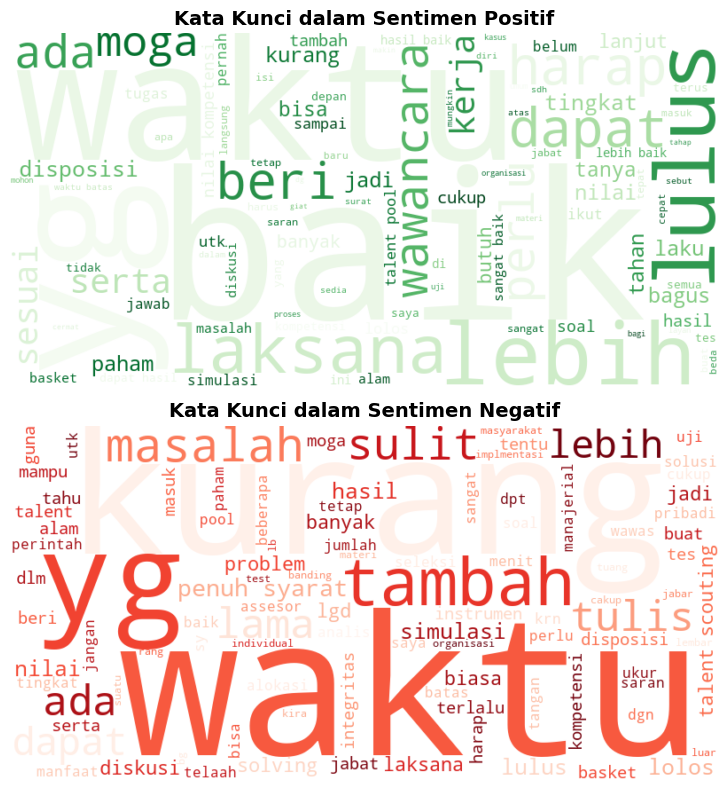

In [9]:
print("\n[7] ANALISIS MENDALAM")
print("Melakukan analisis lebih mendalam terhadap data sentimen...")

print("\n7.1 Analisis Kata Kunci berdasarkan Sentimen")

# Fungsi untuk mendapatkan kata kunci terbanyak berdasarkan sentimen
def get_top_keywords(texts, n=10):
    """
    Mendapatkan kata kunci yang paling sering muncul
    
    Args:
        texts: List teks yang akan dianalisis
        n: Jumlah kata kunci yang akan dikembalikan
        
    Returns:
        Counter object dengan n kata kunci teratas
    """
    all_words = []
    for text in texts:
        if pd.notna(text) and text.strip() != '':
            all_words.extend(text.split())
    
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Analisis kata kunci untuk sentimen positif dan negatif
positive_texts = df_analisis[df_analisis['ml_sentiment'] == 'positif']['teks_bersih']
negative_texts = df_analisis[df_analisis['ml_sentiment'] == 'negatif']['teks_bersih']

print("\nKata kunci terbanyak pada sentimen POSITIF:")
positive_keywords = get_top_keywords(positive_texts)
for word, count in positive_keywords:
    print(f"- {word}: {count}")

print("\nKata kunci terbanyak pada sentimen NEGATIF:")
negative_keywords = get_top_keywords(negative_texts)
for word, count in negative_keywords:
    print(f"- {word}: {count}")

# Visualisasi kata kunci dengan word cloud
if wordcloud_available:
    try:
        # Gabungkan teks positif dan negatif
        positive_text = ' '.join(positive_texts.dropna())
        negative_text = ' '.join(negative_texts.dropna())
        
        # Word cloud untuk sentimen
        plt.figure(figsize=(15, 8))
        
        # Word cloud untuk sentimen positif
        if positive_text.strip():
            wordcloud_positive = WordCloud(
                width=800, height=400,
                background_color='white',
                max_words=100,
                colormap='Greens',
                random_state=42
            ).generate(positive_text)
            
            plt.subplot(2, 1, 1)
            plt.imshow(wordcloud_positive, interpolation='bilinear')
            plt.axis('off')
            plt.title('Kata Kunci dalam Sentimen Positif', fontsize=14, fontweight='bold')
        
        # Word cloud untuk sentimen negatif
        if negative_text.strip():
            wordcloud_negative = WordCloud(
                width=800, height=400,
                background_color='white',
                max_words=100,
                colormap='Reds',
                random_state=42
            ).generate(negative_text)
            
            plt.subplot(2, 1, 2)
            plt.imshow(wordcloud_negative, interpolation='bilinear')
            plt.axis('off')
            plt.title('Kata Kunci dalam Sentimen Negatif', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('wordcloud_sentimen.png', dpi=300, bbox_inches='tight')
        print("\nWord cloud sentimen disimpan sebagai 'wordcloud_sentimen.png'")
    except Exception as e:
        print(f"Gagal membuat word cloud: {str(e)}")


## 7.2 Analisis Tren Sentimen Berdasarkan Waktu


7.2 Analisis Tren Sentimen Berdasarkan Waktu
Memulai analisis tren sentimen berdasarkan waktu...
Data valid untuk analisis: 131 dari 198 total data

Hasil Analisis Tren Sentimen:
Periode: 2022-01
  Total respons: 40
  Sentimen Positif: 36 (90.0%)
  Sentimen Negatif: 4 (10.0%)

Periode: 2022-02
  Total respons: 21
  Sentimen Positif: 18 (85.7%)
  Sentimen Negatif: 3 (14.3%)

Periode: 2022-03
  Total respons: 70
  Sentimen Positif: 60 (85.7%)
  Sentimen Negatif: 10 (14.3%)

Ringkasan Statistik:
- Periode analisis: 2022-01 s/d 2022-03
- Total periode: 3 bulan
- Rata-rata sentimen positif: 87.1%
- Rata-rata sentimen negatif: 12.9%

Bulan dengan sentimen terbaik: 2022-01 (90.0% positif)
Bulan dengan sentimen terburuk: 2022-02 (85.7% positif)

✓ Grafik tren sentimen disimpan sebagai 'tren_sentimen.png'


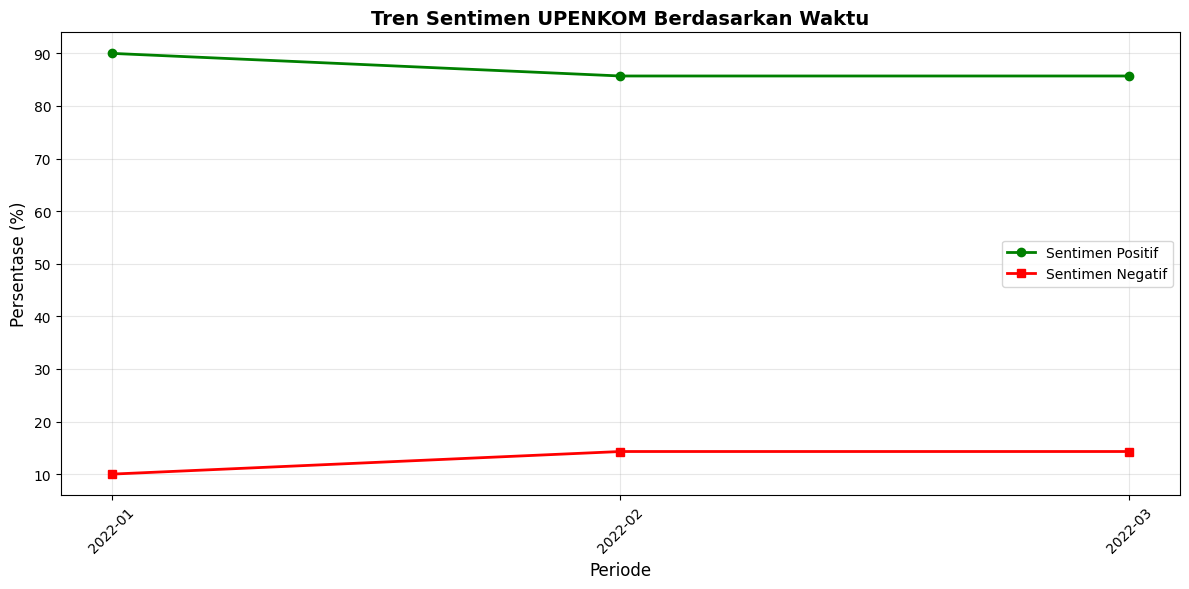

In [10]:
# 7.2 Analisis Tren Sentimen Berdasarkan Waktu
print("\n7.2 Analisis Tren Sentimen Berdasarkan Waktu")

def analyze_sentiment_trend(df):
    """
    Fungsi untuk menganalisis tren sentimen berdasarkan waktu
    """
    print("Memulai analisis tren sentimen berdasarkan waktu...")
    
    # Pastikan ada kolom datetime yang sudah diperbaiki
    if 'timestamp_datetime' not in df.columns:
        print("Kolom timestamp_datetime tidak ditemukan. Pastikan data preparation sudah dijalankan.")
        return None
    
    # Filter data yang memiliki timestamp dan sentimen valid
    df_valid = df[(df['timestamp_datetime'].notna()) & (df['ml_sentiment'].notna())].copy()
    
    if len(df_valid) == 0:
        print("Tidak ada data valid untuk analisis tren")
        return None
    
    print(f"Data valid untuk analisis: {len(df_valid)} dari {len(df)} total data")
    
    # Buat kolom periode untuk analisis
    df_valid['bulan_tahun'] = df_valid['timestamp_datetime'].dt.to_period('M')
    
    # Hitung distribusi sentimen per bulan
    tren_bulanan = df_valid.groupby(['bulan_tahun', 'ml_sentiment']).size().unstack(fill_value=0)
    
    # Pastikan kolom positif dan negatif ada
    if 'positif' not in tren_bulanan.columns:
        tren_bulanan['positif'] = 0
    if 'negatif' not in tren_bulanan.columns:
        tren_bulanan['negatif'] = 0
    
    # Hitung total dan persentase
    tren_bulanan['total'] = tren_bulanan.sum(axis=1)
    tren_bulanan['persen_positif'] = (tren_bulanan['positif'] / tren_bulanan['total'] * 100).round(1)
    tren_bulanan['persen_negatif'] = (tren_bulanan['negatif'] / tren_bulanan['total'] * 100).round(1)
    
    # Reset index untuk kemudahan akses
    tren_bulanan = tren_bulanan.reset_index()
    tren_bulanan['bulan_str'] = tren_bulanan['bulan_tahun'].astype(str)
    
    return tren_bulanan

# Jalankan analisis tren
df_tren = analyze_sentiment_trend(df_analisis)

if df_tren is not None:
    print("\nHasil Analisis Tren Sentimen:")
    print("="*60)
    
    # Tampilkan tabel tren
    for _, row in df_tren.iterrows():
        print(f"Periode: {row['bulan_str']}")
        print(f"  Total respons: {int(row['total'])}")
        print(f"  Sentimen Positif: {int(row['positif'])} ({row['persen_positif']}%)")
        print(f"  Sentimen Negatif: {int(row['negatif'])} ({row['persen_negatif']}%)")
        print()
    
    # Ringkasan statistik
    print("Ringkasan Statistik:")
    print(f"- Periode analisis: {df_tren['bulan_str'].iloc[0]} s/d {df_tren['bulan_str'].iloc[-1]}")
    print(f"- Total periode: {len(df_tren)} bulan")
    print(f"- Rata-rata sentimen positif: {df_tren['persen_positif'].mean():.1f}%")
    print(f"- Rata-rata sentimen negatif: {df_tren['persen_negatif'].mean():.1f}%")
    
    # Identifikasi bulan terbaik dan terburuk jika ada lebih dari 1 periode
    if len(df_tren) > 1:
        best_month = df_tren.loc[df_tren['persen_positif'].idxmax()]
        worst_month = df_tren.loc[df_tren['persen_positif'].idxmin()]
        
        print(f"\nBulan dengan sentimen terbaik: {best_month['bulan_str']} ({best_month['persen_positif']}% positif)")
        print(f"Bulan dengan sentimen terburuk: {worst_month['bulan_str']} ({worst_month['persen_positif']}% positif)")
    
    # Visualisasi sederhana jika matplotlib tersedia
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(12, 6))
        
        # Plot tren sentimen
        months = range(len(df_tren))
        plt.plot(months, df_tren['persen_positif'], marker='o', linewidth=2, 
                label='Sentimen Positif', color='green')
        plt.plot(months, df_tren['persen_negatif'], marker='s', linewidth=2, 
                label='Sentimen Negatif', color='red')
        
        plt.title('Tren Sentimen UPENKOM Berdasarkan Waktu', fontsize=14, fontweight='bold')
        plt.xlabel('Periode', fontsize=12)
        plt.ylabel('Persentase (%)', fontsize=12)
        plt.xticks(months, df_tren['bulan_str'], rotation=45)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Simpan grafik
        plt.savefig('tren_sentimen.png', dpi=300, bbox_inches='tight')
        print(f"\n✓ Grafik tren sentimen disimpan sebagai 'tren_sentimen.png'")
        
        plt.show()
        
    except ImportError:
        print("\nMatplotlib tidak tersedia, grafik dilewati")
    except Exception as e:
        print(f"\nGagal membuat grafik: {str(e)}")

else:
    print("Analisis tren tidak dapat dilakukan")